13. This question should be answered using the Weekly data set, which
 is part of the ISLP package. This data is similar in nature to the
 Smarket data from this chapter’s lab, except that it contains 1,089
 weekly returns for 21 years, from the beginning of 1990 to the end of 2010.

 (a) Produce some numerical and graphical summaries of the Weekly
 data. Do there appear to be any patterns?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 改成你實際放的路徑：
Weekly = pd.read_csv('/Users/User-NB/OneDrive/Desktop/ml&fintech/1027/Weekly.csv')

# 建立二元目標（Up=1, Down=0）
Weekly['Direction_bin'] = (Weekly['Direction'].astype(str).str.strip().str.capitalize() == 'Up').astype(int)

Weekly.head()


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction,Direction_bin
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down,0
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down,0
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up,1
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up,1
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           1089 non-null   int64  
 1   Lag1           1089 non-null   float64
 2   Lag2           1089 non-null   float64
 3   Lag3           1089 non-null   float64
 4   Lag4           1089 non-null   float64
 5   Lag5           1089 non-null   float64
 6   Volume         1089 non-null   float64
 7   Today          1089 non-null   float64
 8   Direction      1089 non-null   object 
 9   Direction_bin  1089 non-null   int32  
dtypes: float64(7), int32(1), int64(1), object(1)
memory usage: 80.9+ KB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,1089.0,NaN,NaN,NaN,2000.048669,6.033182,1990.0,1995.0,2000.0,2005.0,2010.0
Lag1,1089.0,NaN,NaN,NaN,0.150585,2.357013,-18.195,-1.154,0.241,1.405,12.026
Lag2,1089.0,NaN,NaN,NaN,0.151079,2.357254,-18.195,-1.154,0.241,1.409,12.026
Lag3,1089.0,NaN,NaN,NaN,0.147205,2.360502,-18.195,-1.158,0.241,1.409,12.026
Lag4,1089.0,NaN,NaN,NaN,0.145818,2.360279,-18.195,-1.158,0.238,1.409,12.026
Lag5,1089.0,NaN,NaN,NaN,0.139893,2.361285,-18.195,-1.166,0.234,1.405,12.026
Volume,1089.0,NaN,NaN,NaN,1.574618,1.686636,0.087465,0.332022,1.00268,2.053727,9.328214
Today,1089.0,NaN,NaN,NaN,0.149899,2.356927,-18.195,-1.154,0.241,1.405,12.026
Direction,1089,2,Up,605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Direction_bin,1089.0,NaN,NaN,NaN,0.555556,0.497132,0.0,0.0,1.0,1.0,1.0


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


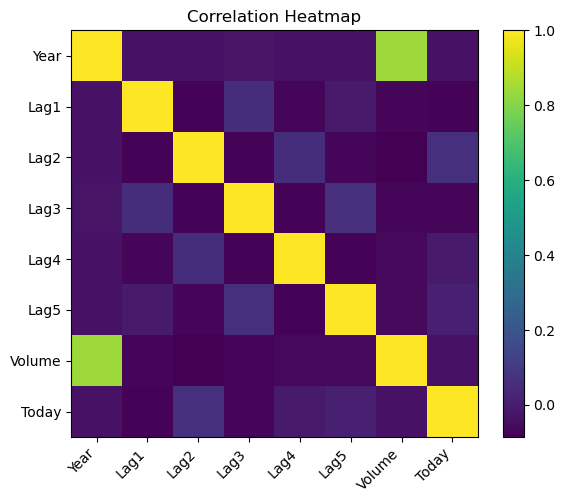

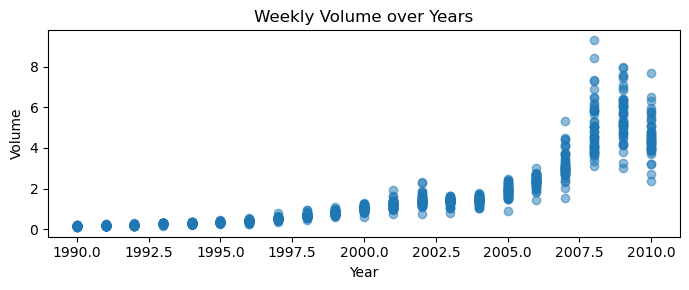

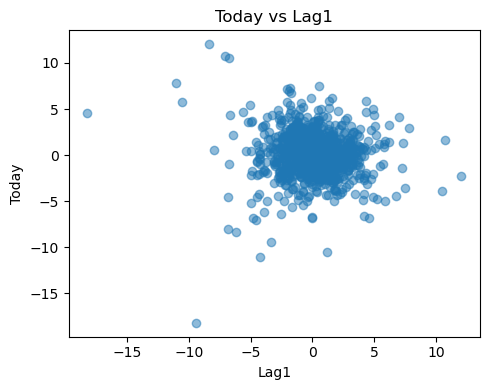

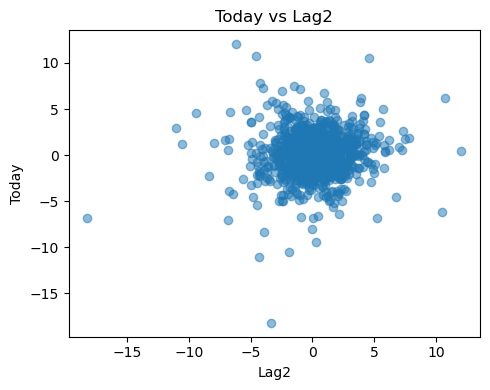

In [4]:
# 數值摘要
print(Weekly.info())
display(Weekly.describe(include='all').T)

# 相關係數
num_cols = ['Year','Lag1','Lag2','Lag3','Lag4','Lag5','Volume','Today']
corr = Weekly[num_cols].corr()
display(corr)

# 相關係數熱力圖
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, interpolation='nearest')
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right'); ax.set_yticklabels(num_cols)
ax.set_title('Correlation Heatmap')
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# Volume 年度趨勢
plt.figure(figsize=(7,3))
plt.plot(Weekly['Year'], Weekly['Volume'], 'o', alpha=0.5)
plt.title('Weekly Volume over Years'); plt.xlabel('Year'); plt.ylabel('Volume')
plt.tight_layout(); plt.show()

# Today vs Lag1 / Lag2 散佈圖
plt.figure(figsize=(5,4))
plt.scatter(Weekly['Lag1'], Weekly['Today'], alpha=0.5)
plt.title('Today vs Lag1'); plt.xlabel('Lag1'); plt.ylabel('Today')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5,4))
plt.scatter(Weekly['Lag2'], Weekly['Today'], alpha=0.5)
plt.title('Today vs Lag2'); plt.xlabel('Lag2'); plt.ylabel('Today')
plt.tight_layout(); plt.show()


 (b) Use the full data set to perform a logistic regression with
 Direction as the response and the five lag variables plus Volume
 as predictors. Use the summary function to print the results. Do
 any of the predictors appear to be statistically significant? If so,
 which ones?

In [8]:
import statsmodels.formula.api as smf

formula = 'Direction_bin ~Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume'
logit_full = smf.logit(formula = formula, data= Weekly).fit()
print(logit_full.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          Direction_bin   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Mon, 03 Nov 2025   Pseudo R-squ.:                0.006580
Time:                        01:23:57   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

 (c) Compute the confusion matrix and overall fraction of correct
 predictions. Explain what the confusion matrix is telling you
 about the types of mistakes made by logistic regression.

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

proba_full = logit_full.predict(Weekly)
pred_full = (proba_full >= 0.5).astype(int)

# 混淆矩陣（列=true實際值, 行=預測值; 0=Down, 1=Up）
cm_full = confusion_matrix(Weekly['Direction_bin'], pred_full, labels=[0,1])
acc_full = accuracy_score(Weekly['Direction_bin'], pred_full)

print("Confusion Matrix:\n", cm_full)
print("\nOverall Accuracy:", round(acc_full,4))
print("\nClassification Report:\n", classification_report(Weekly['Direction_bin'], pred_full, target_names=['Down','Up']))


Confusion Matrix:
 [[ 54 430]
 [ 48 557]]

Overall Accuracy: 0.5611

Classification Report:
               precision    recall  f1-score   support

        Down       0.53      0.11      0.18       484
          Up       0.56      0.92      0.70       605

    accuracy                           0.56      1089
   macro avg       0.55      0.52      0.44      1089
weighted avg       0.55      0.56      0.47      1089



The confusion matrix shows that the logistic regression model tends to predict “Up” for most weeks.
Out of 484 actual “Down” weeks, only 54 were correctly predicted, while 430 were misclassified as “Up.”
The overall accuracy is 56.1%, slightly better than random guessing.
The model has a high recall for “Up” (0.92) but a very low recall for “Down” (0.11), indicating a strong bias toward predicting upward movements.

 (d) Now fit the logistic regression model using a training data period
 from 1990 to 2008, with Lag2 as the only predictor. Compute the
 confusion matrix and the overall fraction of correct predictions
 for the held out data (that is, the data from 2009 and 2010).

In [12]:
# 分割訓練與測試集
train = Weekly[Weekly['Year'] <= 2008]
test  = Weekly[Weekly['Year'] >= 2009]

# 用 Lag2 當唯一自變數
logit_lag2 = smf.logit('Direction_bin ~ Lag2', data=train).fit()
print(logit_lag2.summary())

# 對測試資料預測
proba_test = logit_lag2.predict(test)
pred_test = (proba_test >= 0.5).astype(int)

# 混淆矩陣與正確率
cm_test = confusion_matrix(test['Direction_bin'], pred_test, labels=[0,1])
acc_test = accuracy_score(test['Direction_bin'], pred_test)

print("\nTest Confusion Matrix:\n", cm_test)
print("\nTest Accuracy:", round(acc_test,4))
print("\nTest Classification Report:\n", classification_report(test['Direction_bin'], pred_test, target_names=['Down','Up']))


Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          Direction_bin   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Mon, 03 Nov 2025   Pseudo R-squ.:                0.003076
Time:                        01:31:00   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.

Using data from 1990–2008, a logistic regression model with Lag2 as the only predictor was trained and evaluated on 2009–2010 data.
The coefficient of Lag2 (0.0581, p=0.043) is positive and significant, indicating a weak but statistically meaningful momentum effect: higher returns two weeks ago slightly increase the likelihood of an “Up” week.

The overall accuracy is 62.5%, which is higher than the 56% obtained in (c).
The model still tends to predict “Up,” but performs better out-of-sample, suggesting Lag2 carries modest predictive information.